# Exercises for Chapter 22: Advanced regression and multilevel models

In [40]:
import os
import sys

from matplotlib import pyplot
from scipy import stats

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [41]:
prng_builder = bg_ros.PRNGBuilder('# Exercises for Chapter 22: Advanced regression and multilevel models')

## 22.1, Measurement error in $y$

> Simulate data $(x, y)_i, i = 1, \ldots, n$ from a linear regression model,
> $y = a + bx + \text{error}$, but suppose that the outcome $y$ is not observed
> directly, but instead we observe $v = y + \text{error}$, with independent
> measurement errors with mean zero.  Use simulations to understand the
> statistical properties of the observed-data regression of $v$ on $x$, compared
> to the desired regression of $y$ on $x$.

In [42]:
rng = prng_builder.new('22.1, Measurement error in y')

In [43]:
num_sims = 500
n = 200
a = -1
b = 3
sigma = 2
# Key: (n, v_err)
results = {}
v_errs = [0.3, 1, 3]
ns = [50, 100, 200]
for n in ns:
    for v_err in v_errs:
        key = (n, v_err)
        results[key] = []
        for _ in range(num_sims):
            xs = rng.normal(scale=4, size=n)
            ys = rng.normal(loc=(a + b * xs), scale=sigma)
            vs = rng.normal(loc=ys, scale=v_err)
            model = stats.linregress(xs, vs)
            results[key].append(model.slope)    

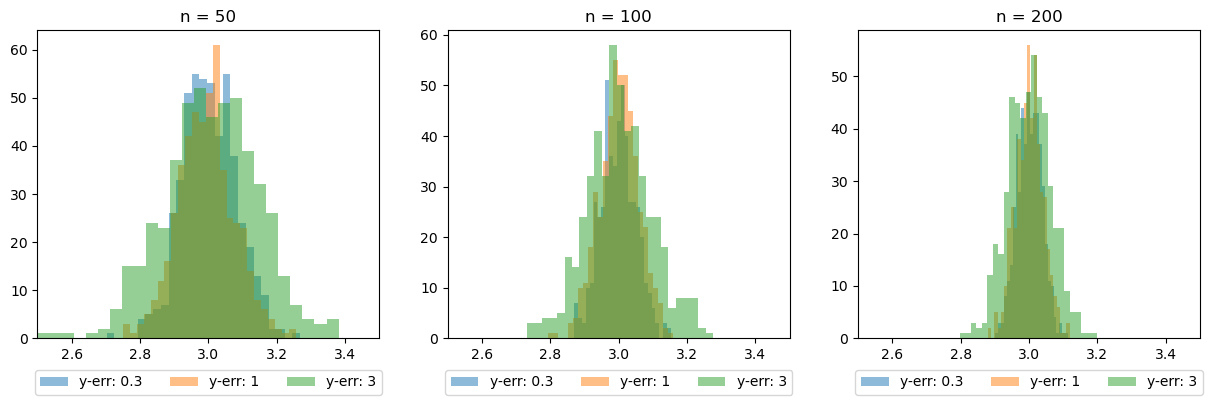

In [44]:
fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(15, 4))

for ax, n in zip(axs, ns):
    for v_err in v_errs:
        ax.hist(
            results[(n, v_err)],
            bins=25,
            alpha=0.5,
            label=f'y-err: {v_err}',
        )
    ax.set_title(f'n = {n}')
    ax.set_xlim(2.5, 3.5)
    ax.legend(ncols=3, loc='upper center', bbox_to_anchor=(0.5, -0.08))

## 22.2, Measurement error in $x$

> Simulate data $(x, y)_i, i = 1, \ldots, n$ from a linear regression model,
> $y = a + bx + \text{error}$, but suppose that the predictor $x$ is not
> observed directly, but instead we observe $u = x + \text{error}$, with
> independent measurement errors with mean zero.  Use simulations to understand
> the statistical properties of the observed-data regression of $y$ on $u$,
> compared to the desired regression of $y$ on $x$.

In [45]:
rng = prng_builder.new('Now it is time for 22.1, Measurement error in x')

In [46]:
num_sims = 500
n = 200
a = -1
b = 3
sigma = 2
# Key: (n, u_err)
results = {}
u_errs = [0.5, 1, 2]
ns = [50, 100, 200]
for n in ns:
    for u_err in u_errs:
        key = (n, u_err)
        results[key] = []
        for _ in range(num_sims):
            xs = rng.normal(scale=4, size=n)
            ys = rng.normal(loc=(a + b * xs), scale=sigma)
            us = rng.normal(loc=xs, scale=u_err)
            model = stats.linregress(us, ys)
            results[key].append(model.slope)    

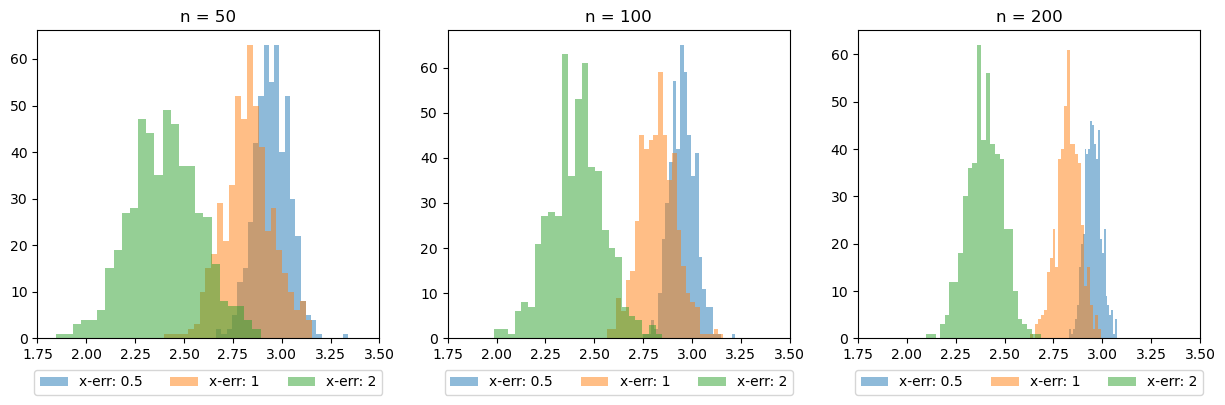

In [49]:
fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(15, 4))

for ax, n in zip(axs, ns):
    for u_err in u_errs:
        ax.hist(
            results[(n, u_err)],
            bins=25,
            alpha=0.5,
            label=f'x-err: {u_err}',
        )
    ax.set_title(f'n = {n}')
    ax.set_xlim(1.75, 3.5)
    ax.legend(ncols=3, loc='upper center', bbox_to_anchor=(0.5, -0.08))